In [1]:
%%shell
git clone https://github.com/ClementPinard/SfmLearner-Pytorch
cd SfmLearner-Pytorch
pip install -qr requirements.txt
mkdir -p pretrained
gdown --fuzzy https://drive.google.com/file/d/1o-cKKbq8jGvjaiEKuKWDjEMmI5Y4PN9K/view?usp=sharing -O pretrained/exp_pose_model_best.pth.tar
gdown --fuzzy https://drive.google.com/file/d/1SOyTw_XDzirdf-tSz_TV7HjAG4wWB3nr/view?usp=sharing -O pretrained/dispnet_model_best.pth.tar
gdown --fuzzy https://drive.google.com/file/d/1AjRNHg-OuN6K9ygzsikRxqcRb5J_i0dv/view?usp=sharing -O odometry.zip
unzip odometry.zip > /dev/null

Cloning into 'SfmLearner-Pytorch'...
remote: Enumerating objects: 556, done.
remote: Total 556 (delta 0), reused 0 (delta 0), pack-reused 556
Receiving objects: 100% (556/556), 6.75 MiB | 21.41 MiB/s, done.
Resolving deltas: 100% (342/342), done.
     |████████████████████████████████| 125 kB 49.4 MB/s 
Downloading...
From: https://drive.google.com/uc?id=1o-cKKbq8jGvjaiEKuKWDjEMmI5Y4PN9K
To: /content/SfmLearner-Pytorch/pretrained/exp_pose_model_best.pth.tar
100% 6.40M/6.40M [00:00<00:00, 12.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1SOyTw_XDzirdf-tSz_TV7HjAG4wWB3nr
To: /content/SfmLearner-Pytorch/pretrained/dispnet_model_best.pth.tar
100% 126M/126M [00:02<00:00, 45.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1AjRNHg-OuN6K9ygzsikRxqcRb5J_i0dv
To: /content/SfmLearner-Pytorch/odometry.zip
100% 549M/549M [00:11<00:00, 47.3MB/s]


In [2]:
%%shell
cd SfmLearner-Pytorch
# mkdir -p odometry/output/01_chair
# python test_pose.py pretrained/exp_pose_model_best.pth.tar --dataset-dir odometry --sequences 01_chair --output-dir odometry/output/01_chair
mkdir -p odometry/output/02_screen
python test_pose.py pretrained/exp_pose_model_best.pth.tar --dataset-dir odometry --sequences 02_screen --output-dir odometry/output/02_screen

getting test metadata for theses sequences : {Path('odometry/sequences/02_screen')}
100% 1/1 [00:00<00:00, 99.94it/s]
300 snippets to test
 99% 296/300 [06:37<00:05,  1.34s/it]

Results
	        ATE,         RE
mean 	     0.8306,     0.0928
std 	     4.3911,     0.1380


In [3]:
import numpy as np
import pandas as pd
import plotly.express as px


def rel2abs(predictions):
    # See: https://github.com/ClementPinard/SfmLearner-Pytorch/issues/120

    for i in range(1, len(predictions)):
        r = predictions[i - 1, 1]
        predictions[i] = r[:, :3] @ predictions[i]
        predictions[i, :, :, -1] = predictions[i, :, :, -1] + r[:, -1]

    return predictions


def to_path(predictions, type_):
    # The coordinate systems are defined the following way, where directions
    # are informally given from the drivers view, when looking forward onto
    # the road:
    # x: right,   y: down,  z: forward

    path = []
    prev = {"x": 0, "y": 0, "z": 0, "length": 0, "type": type_}
    length = 0
    for i in range(predictions.shape[1]):
        x = predictions[0, i, 0, 3]
        y = predictions[0, i, 2, 3]
        z = -predictions[0, i, 1, 3]

        curr = {"x": x, "y": y, "z": z, "length": prev["length"], "type": type_}
        curr["length"] += ((curr["x"] - prev["x"]) ** 2 + (curr["y"] - prev["y"]) ** 2 + (curr["z"] - prev["z"]) ** 2) ** 0.5

        path.append(curr)
        prev = curr

    for i in range(1, predictions.shape[0]):
        x = predictions[i, -1, 0, 3]
        y = predictions[i, -1, 2, 3]
        z = -predictions[i, -1, 1, 3]

        curr = {"x": x, "y": y, "z": z, "length": prev["length"], "type": type_}
        curr["length"] += ((curr["x"] - prev["x"]) ** 2 + (curr["y"] - prev["y"]) ** 2 + (curr["z"] - prev["z"]) ** 2) ** 0.5

        path.append(curr)
        prev = curr

    return pd.DataFrame(path)

In [4]:
pred_poses = rel2abs(np.load("SfmLearner-Pytorch/odometry/output/02_screen/predictions.npy"))
pred_path = to_path(pred_poses, type_="pred")

fig = px.scatter_3d(pred_path, x="x", y="y", z="z", color="type", hover_data=["length"])
fig.update_layout(scene=dict(aspectmode="data"))
fig.show()

In [5]:
%%shell
cd SfmLearner-Pytorch
# mkdir -p odometry/output/01_chair/disp_depth
# python run_inference.py --pretrained pretrained/dispnet_model_best.pth.tar --dataset-dir odometry/sequences/01_chair/image_2 --output-dir odometry/output/01_chair/disp_depth --output-disp --output-depth --img-width 416 --img-height 234
mkdir -p odometry/output/02_screen/disp_depth
python run_inference.py --pretrained pretrained/dispnet_model_best.pth.tar --dataset-dir odometry/sequences/02_screen/image_2 --output-dir odometry/output/02_screen/disp_depth --output-disp --output-depth --img-width 416 --img-height 234

300 files to test
100% 300/300 [03:09<00:00,  1.59it/s]


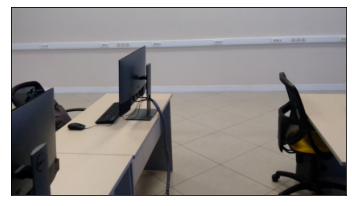

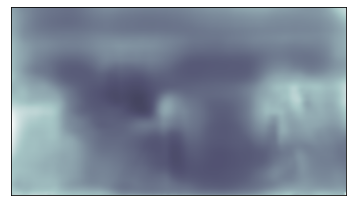

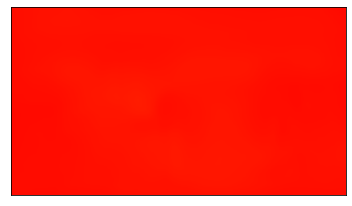

In [14]:
from skimage import io
from skimage.transform import resize
import matplotlib.pyplot as plt

FRAME_IDX = 1
image = resize(io.imread(f"SfmLearner-Pytorch/odometry/sequences/02_screen/image_2/frame_{FRAME_IDX:03}.png"), (234, 416))
disp = io.imread(f"SfmLearner-Pytorch/odometry/output/02_screen/disp_depth/frame_{FRAME_IDX:03}_disp.png")
depth = io.imread(f"SfmLearner-Pytorch/odometry/output/02_screen/disp_depth/frame_{FRAME_IDX:03}_depth.png")

plt.imshow(image)
plt.xticks([])
plt.yticks([])
plt.show()
plt.imshow(disp)
plt.xticks([])
plt.yticks([])
plt.show()
plt.imshow(depth)
plt.xticks([])
plt.yticks([])
plt.show()